In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/mwd_data.csv")

df.head()


,Depth (m),WOB (klbs),RPM,Flow Rate (gpm),Mud Weight (ppg),Torque (kN.m),Standpipe Pressure (psi),Inclination (deg),ROP (m/hr)
0,1000.000000,21.236204,149.816171,392.566464,11.595409,26.228189,578.385110,4.741930,44.120210
1,1004.008016,38.521429,133.609637,570.950474,11.395909,35.206473,580.849463,1.783236,45.384758
2,1008.016032,31.959818,110.952762,736.472918,9.128210,35.007835,451.587286,0.000000,47.860260
3,1012.024048,27.959755,161.379502,666.112443,10.706239,36.057186,538.910173,2.081282,47.989627
4,1016.032064,14.680559,148.473117,703.280574,10.900978,32.228844,556.622904,0.000000,38.944160


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Depth (m)                 500 non-null    float64
 1   WOB (klbs)                500 non-null    float64
 2   RPM                       500 non-null    float64
 3   Flow Rate (gpm)           500 non-null    float64
 4   Mud Weight (ppg)          500 non-null    float64
 5   Torque (kN.m)             500 non-null    float64
 6   Standpipe Pressure (psi)  500 non-null    float64
 7   Inclination (deg)         500 non-null    float64
 8   ROP (m/hr)                500 non-null    float64
dtypes: float64(9)
memory usage: 35.3 KB


In [3]:
df.describe()

,Depth (m),WOB (klbs),RPM,Flow Rate (gpm),Mud Weight (ppg),Torque (kN.m),Standpipe Pressure (psi),Inclination (deg),ROP (m/hr)
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2000.000000,24.956851,128.195139,558.779061,11.482382,52.566973,591.045419,2.163504,31.002550
std,579.085502,8.960652,28.549346,148.596466,1.435049,13.501485,74.672790,1.752622,12.354045
min,1000.000000,10.151848,80.463202,302.469990,9.016091,13.989169,439.792196,0.000000,-1.717438
25%,1500.000000,17.238391,102.909925,420.614024,10.205371,43.379298,525.010673,0.702923,21.561941
50%,2000.000000,25.394912,127.182157,569.869168,11.544457,51.702794,594.397753,1.950352,31.693982
75%,2500.000000,32.683746,152.633682,688.671879,12.686881,62.512558,649.790865,3.251070,39.792915
max,3000.000000,39.788944,179.971767,799.706863,13.991738,86.929106,768.024572,10.227225,64.160980


### checking:
#### ranges (are they realistic?)
#### missing values
#### data type correctness

In [4]:
df.isnull().sum()

Depth (m)                   0
WOB (klbs)                  0
RPM                         0
Flow Rate (gpm)             0
Mud Weight (ppg)            0
Torque (kN.m)               0
Standpipe Pressure (psi)    0
Inclination (deg)           0
ROP (m/hr)                  0
dtype: int64

#### Expected result:

##### all zeros (because we are using simulated data)

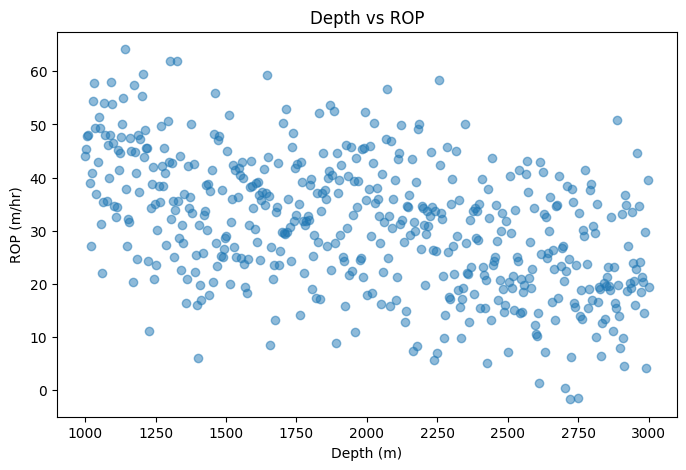

In [7]:
plt.figure(figsize=(8,5))
plt.scatter(df["Depth (m)"], df["ROP (m/hr)"], alpha=0.5)
plt.title("Depth vs ROP")
plt.xlabel("Depth (m)")
plt.ylabel("ROP (m/hr)")
plt.show()

##### ROP generally decreases with depth due to increasing formation hardness and drilling resistance.

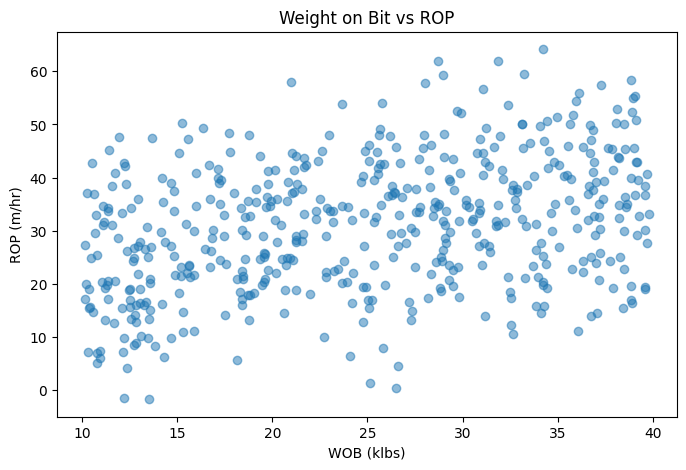

In [8]:
plt.figure(figsize=(8,5))
plt.scatter(df["WOB (klbs)"], df["ROP (m/hr)"], alpha=0.5)
plt.title("Weight on Bit vs ROP")
plt.xlabel("WOB (klbs)")
plt.ylabel("ROP (m/hr)")
plt.show()

##### Increasing WOB generally improves ROP until mechanical limitations or formation effects dominate.

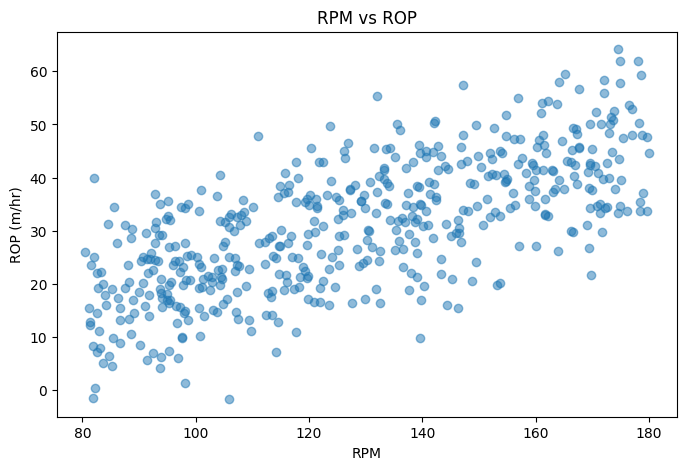

In [9]:
plt.figure(figsize=(8,5))
plt.scatter(df["RPM"], df["ROP (m/hr)"], alpha=0.5)
plt.title("RPM vs ROP")
plt.xlabel("RPM")
plt.ylabel("ROP (m/hr)")
plt.show()

##### Higher RPM contributes to improved drilling efficiency, but interaction with WOB is critical.

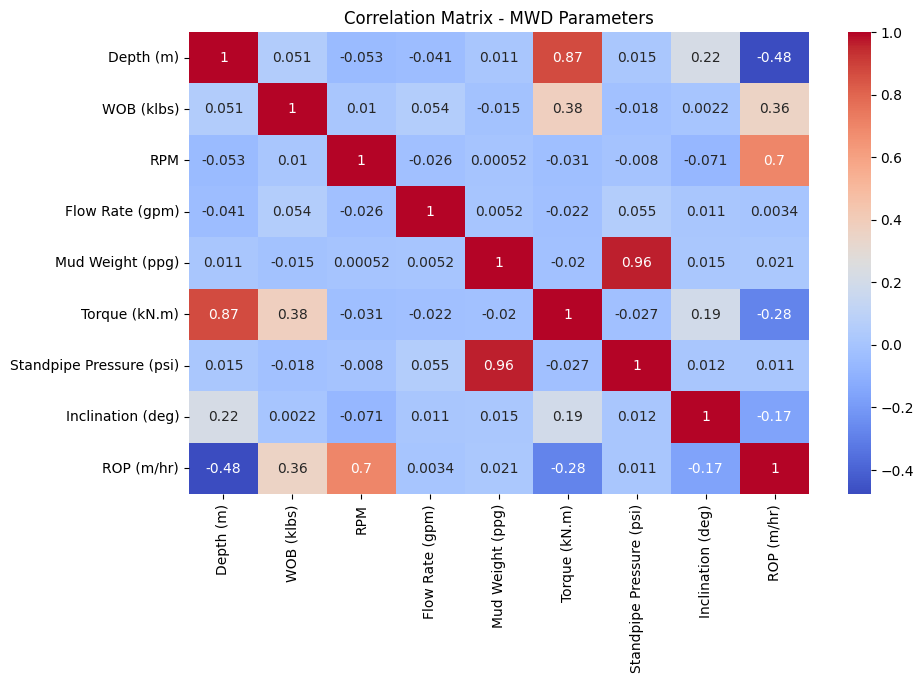

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix - MWD Parameters")
plt.show()

## Key Observations

- Depth shows negative correlation with ROP
- WOB and RPM positively influence drilling performance
- Flow rate and mud properties affect system stability
- Drilling performance is a multi-variable coupled system